In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set plotting style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv('../../data/renewal_calls.csv')

print(f"Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\1550746023.py:11: DtypeWarning: Columns (0: Churn_Category, 1: Complaint_Category, 2: Customer_Reaction_Category, 3: Agent_Renewal_Pitch_Category, 4: Customer_Renewal_Response_Category, 5: Agent_Response_Category, 6: Membership_Renewal_Decision, 7: Serious_Complaint, 8: Other_Complaint, 9: Discussion_on_Price_Increase, 10: Renewal_Impact_Due_to_Price_Increase, 11: Discount_or_Waiver_Requested, 12: Call_Reschedule_Request, 13: Agent_Flagged_Membership_Status_Alert, 14: Agent_Renewal_Initiation, 15: Explicit_Competitor_Mention, 16: Explicit_Switching_Intent, 17: Mentioned_Competitors, 18: Price_Switching_Mentioned, 19: Competitor_Value_Comparison, 20: Competitor_Benefits_Mentioned, 21: Topic_Introduced_By, 22: Percentage_Price_Increase_Mentioned, 23: Monetary_Price_Increase_Mentioned, 24: Price_Range_Mentioned, 25: Customer_Asked_For_Justification, 26: Customer_Response, 27: Desire_To_Cancel, 28: Discount_Offered, 29: Justifi

Shape: (186534, 41)

Data Types:
Call_ID                                              float64
Call_Direction                                           str
Co_Ref                                                   str
Call_Date                                                str
Churn_Category                                           str
Complaint_Category                                       str
Customer_Reaction_Category                               str
Agent_Renewal_Pitch_Category                             str
Customer_Renewal_Response_Category                       str
Agent_Response_Category                                  str
Membership_Renewal_Decision                              str
Serious_Complaint                                        str
Other_Complaint                                          str
Discussion_on_Price_Increase                             str
Renewal_Impact_Due_to_Price_Increase                     str
Discount_or_Waiver_Requested                        

,Call_ID,Call_Direction,Co_Ref,Call_Date,Churn_Category,Complaint_Category,Customer_Reaction_Category,Agent_Renewal_Pitch_Category,Customer_Renewal_Response_Category,Agent_Response_Category,...,Customer_Response,Desire_To_Cancel,Discount_Offered,Justification_Category,Reason_For_Renewal_Category,Agent_Response_To_Cancel_Category,Argument_That_Convinced_Customer_to_Stay_Category,Analysed_Call,Call_Number,Call_Year
0,5.950000e+11,Outbound,UB0899,29-01-2025,NaN,NaN,Not Mentioned,Discussion / Introduction / Inquiry,Discount and Offer,Discount and Offer,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,3,2025
1,5.970000e+11,OUT_BOUND,HN5141,26-02-2025,NaN,NaN,NaN,Price and Cost,Agreement,Customer Communication,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,2,2025
2,5.950000e+11,Outbound,BP5009,24-01-2025,NaN,NaN,NaN,Expiration / Due,Agreement,Accreditation and Certification,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,1,2025
3,6.520000e+11,OUT_BOUND,XP8119,09-06-2025,NaN,NaN,NaN,Auto / Automatic,Agreement,Accreditation and Certification,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,1,2025
4,5.370000e+11,Outbound,ZL7978,20-08-2024,NaN,NaN,NaN,NaN,NaN,NaN,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,28,2024


##### DATA INVENTORY & LEAKAGE WARNING 

**The following columns are considered LEAKAGE - exploration only, never features:**
* `Membership_Renewal_Decision` — this IS the outcome label
* `Churn_Category` — describes why they churned, only known post-decision
* `Desire_To_Cancel` — post-decision signal
* `Customer_Renewal_Response_Category` — outcome-derived
* `Customer_Reaction_Category` — reaction after decision

**Note:** There is a blank unnamed column between `Explicit_Competitor_Mention` and `Explicit_Switching_Intent` — flag this for dropping in the cleaner.

In [34]:
# Column inventory, dtypes and null counts
inventory_df = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df)) * 100
})
display(inventory_df)

,dtype,missing_count,missing_pct
Call_ID,float64,0,0.000000
Call_Direction,str,0,0.000000
Co_Ref,str,7385,3.959064
Call_Date,str,0,0.000000
Churn_Category,str,178632,95.763775
Complaint_Category,str,167526,89.809901
Customer_Reaction_Category,str,163449,87.624240
Agent_Renewal_Pitch_Category,str,132796,71.191311
Customer_Renewal_Response_Category,str,132222,70.883592
Agent_Response_Category,str,132554,71.061576


## Call Year Distribution
Unlike `cc_calls`, this file has strong 2024 coverage — this is our most historically complete behavioural file.

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\4024223876.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Call_Year', order=df['Call_Year'].value_counts().index, palette='viridis')


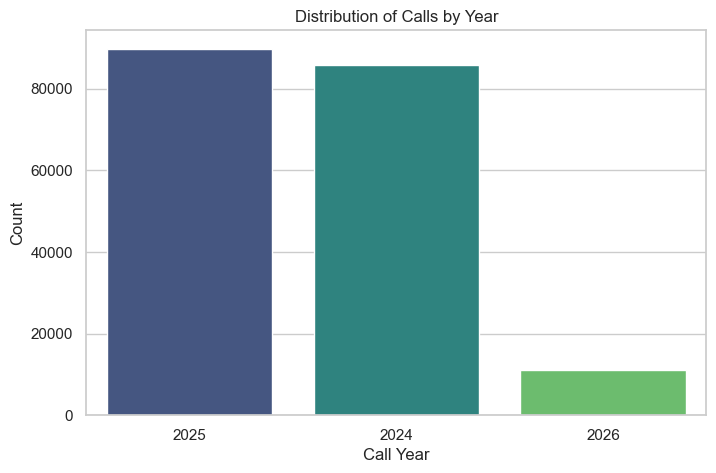


Value Counts:
Call_Year
2025    89819
2024    85751
2026    10964
Name: count, dtype: int64


In [35]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Call_Year', order=df['Call_Year'].value_counts().index, palette='viridis')
plt.title('Distribution of Calls by Year')
plt.xlabel('Call Year')
plt.ylabel('Count')
plt.show()

print("\nValue Counts:")
print(df['Call_Year'].value_counts(dropna=False))

## Call Direction Cleanup
Call_Direction has mixed formats. You will see 4 values instead of 2. Flag this for normalisation in cleaner.py immediately.

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\1930177853.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Call_Direction', order=df['Call_Direction'].value_counts().index, palette='Set2')


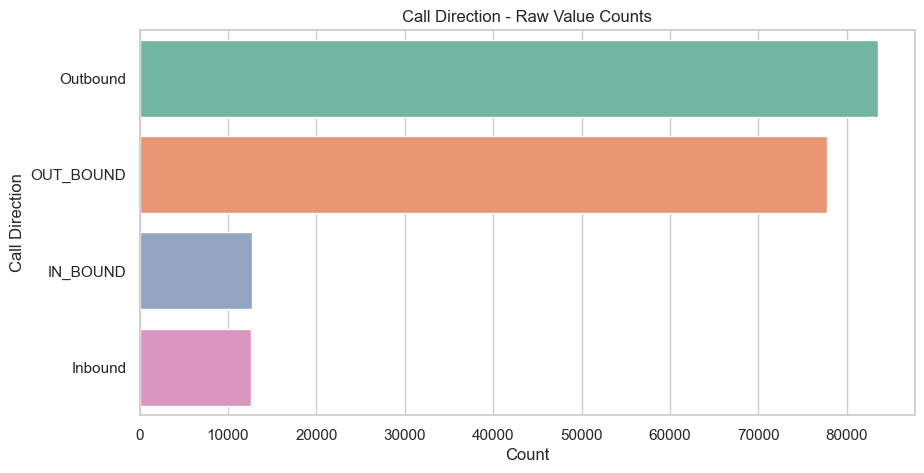


Raw Value Counts:
Call_Direction
Outbound     83493
OUT_BOUND    77719
IN_BOUND     12731
Inbound      12591
Name: count, dtype: int64


In [36]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Call_Direction', order=df['Call_Direction'].value_counts().index, palette='Set2')
plt.title('Call Direction - Raw Value Counts')
plt.xlabel('Count')
plt.ylabel('Call Direction')
plt.show()

print("\nRaw Value Counts:")
print(df['Call_Direction'].value_counts(dropna=False))

## Renewal Decision (Exploration Only)
> **Note:** This column is our proxy label for exploration only. We never use it as a feature — only as a lens to understand behaviour.

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\2738789582.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Membership_Renewal_Decision', ax=ax[0], palette='pastel')


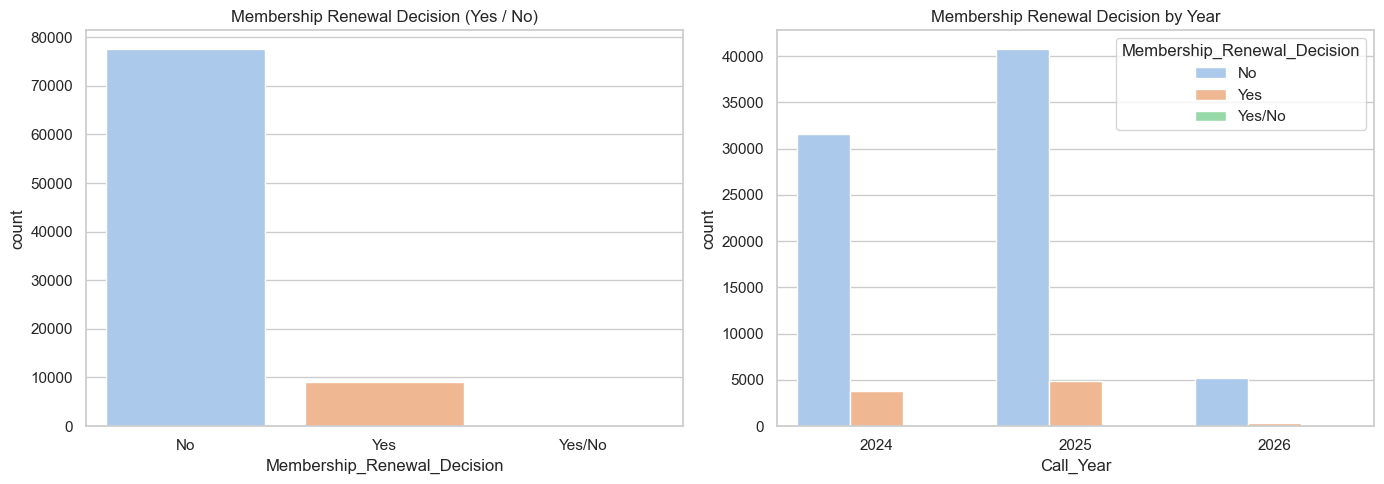

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
sns.countplot(data=df, x='Membership_Renewal_Decision', ax=ax[0], palette='pastel')
ax[0].set_title('Membership Renewal Decision (Yes / No)')

# Split by year (is renewal rate changing year over year?)
sns.countplot(data=df, x='Call_Year', hue='Membership_Renewal_Decision', ax=ax[1], palette='pastel')
ax[1].set_title('Membership Renewal Decision by Year')

plt.tight_layout()
plt.show()

## Churn Reasons (Exploration Only / Business Intelligence)
What are the top reasons customers give for not renewing?

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\148419695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_churn.index, x=top_churn.values, ax=ax[0], palette="Reds_r")
C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\148419695.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=complaints.index, x=complaints.values, ax=ax[1], palette="Oranges_r")


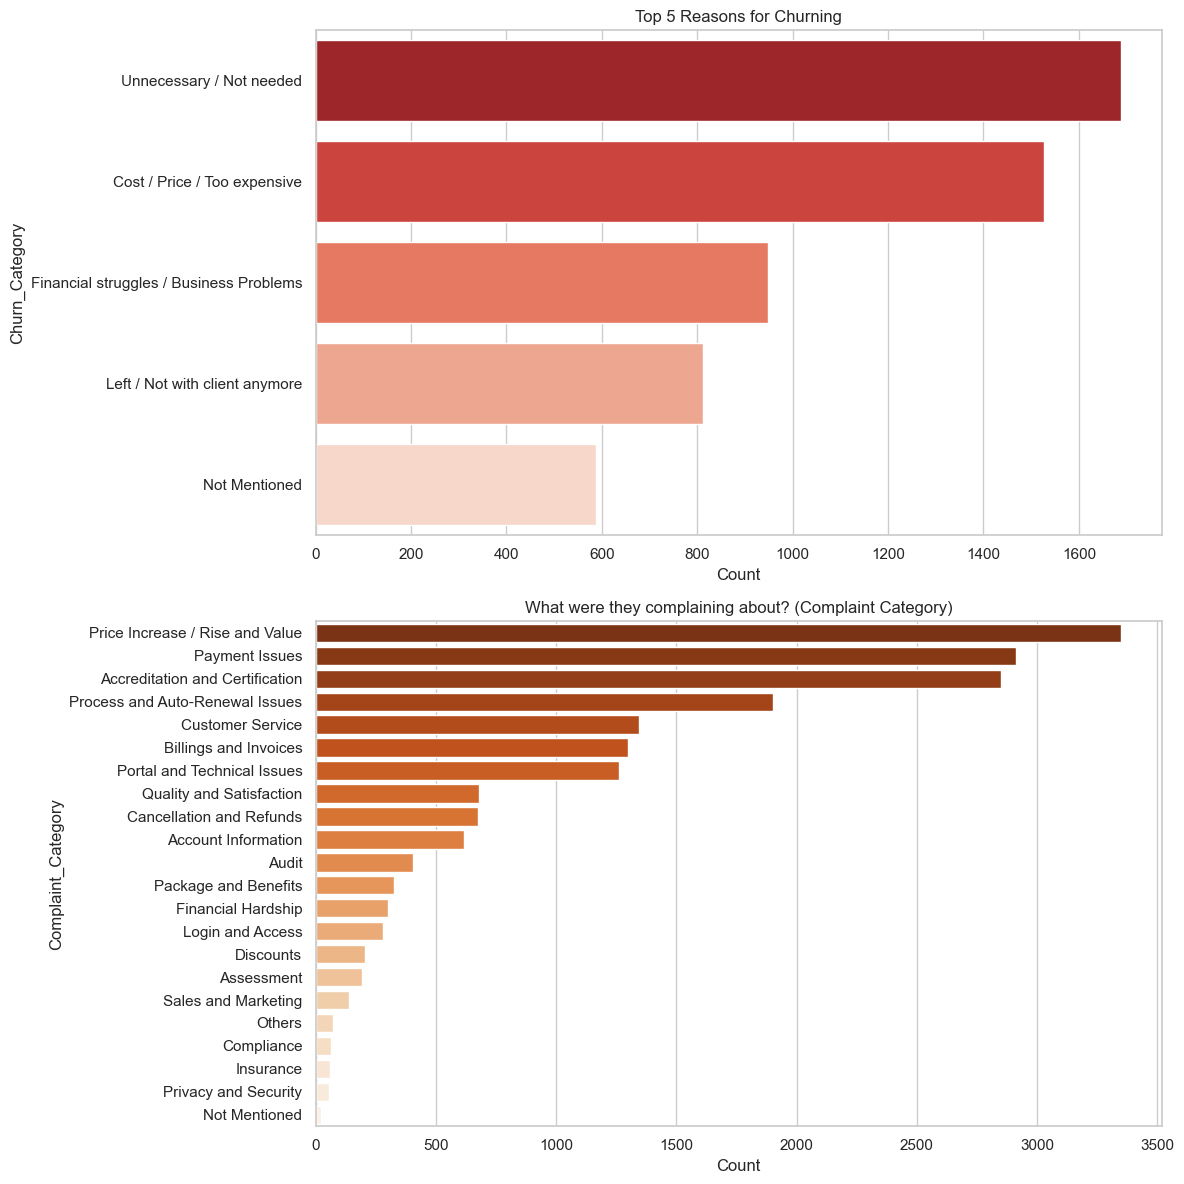

In [38]:
fig, ax = plt.subplots(2, 1, figsize=(12, 12))

# Top churn reasons
top_churn = df['Churn_Category'].value_counts().head(5)
sns.barplot(y=top_churn.index, x=top_churn.values, ax=ax[0], palette="Reds_r")
ax[0].set_title('Top 5 Reasons for Churning')
ax[0].set_xlabel('Count')

# Complaint category
complaints = df['Complaint_Category'].value_counts()
sns.barplot(y=complaints.index, x=complaints.values, ax=ax[1], palette="Oranges_r")
ax[1].set_title('What were they complaining about? (Complaint Category)')
ax[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## Customer Coverage

Total Call Records: 186534
Unique Customers (Co_Ref) with renewal calls: 36303
Calls with null Co_Ref (Flagged): 7385


C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\1038666203.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=unique_by_year, x='Call_Year', y='Co_Ref', palette='mako')


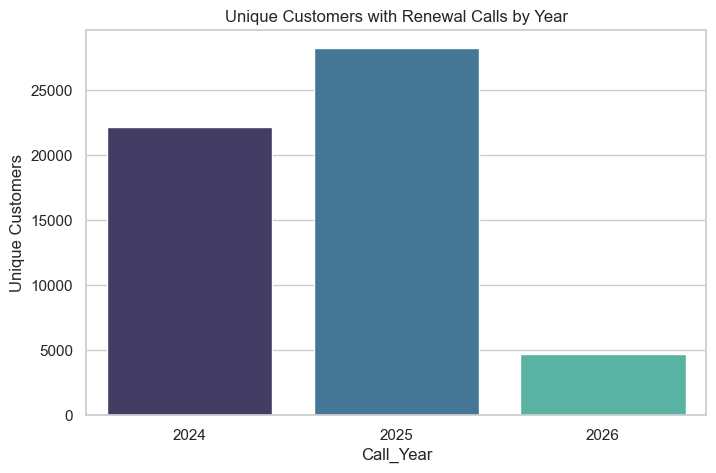

In [39]:
print(f"Total Call Records: {len(df)}")
unique_customers = df['Co_Ref'].nunique()
print(f"Unique Customers (Co_Ref) with renewal calls: {unique_customers}")
null_coref = df['Co_Ref'].isnull().sum()
print(f"Calls with null Co_Ref (Flagged): {null_coref}")

# Unique customers with renewal calls by year
plt.figure(figsize=(8, 5))
unique_by_year = df.dropna(subset=['Co_Ref']).groupby('Call_Year')['Co_Ref'].nunique().reset_index()
sns.barplot(data=unique_by_year, x='Call_Year', y='Co_Ref', palette='mako')
plt.title('Unique Customers with Renewal Calls by Year')
plt.ylabel('Unique Customers')
plt.show()

## Call Number / Friction Signal
Most customers = 1-2 calls. Customers with high call numbers are friction cases.

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\586603042.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_calls, x='Membership_Renewal_Decision', y='Call_Number', ax=ax[1], palette='muted')


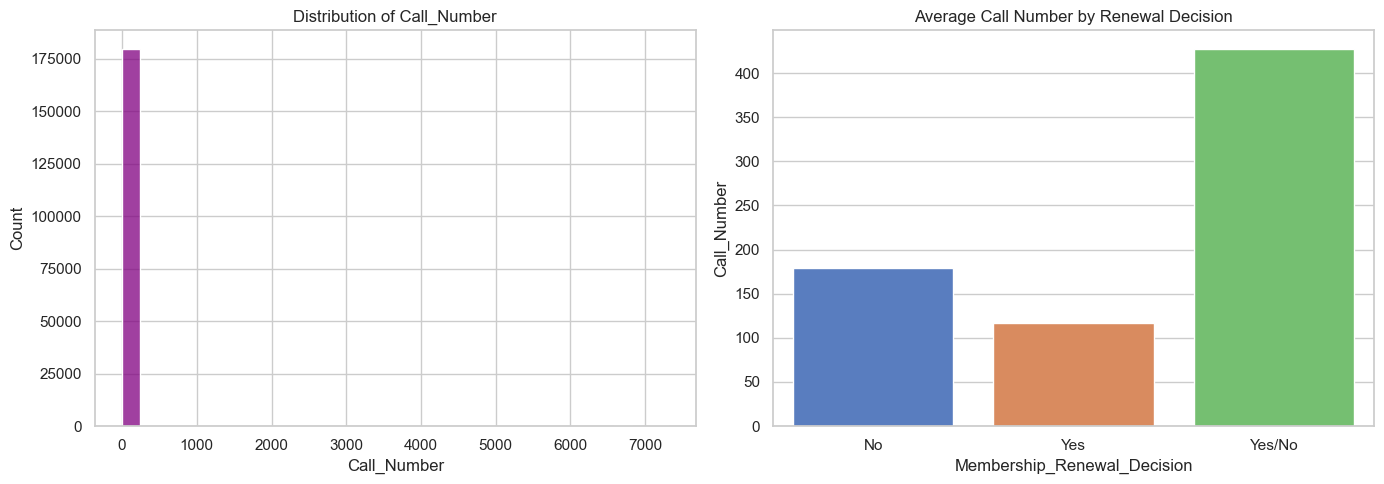

In [40]:
# Values like 1, 2, 3, 7, 28 are visible
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(data=df, x='Call_Number', bins=30, ax=ax[0], color='purple')
ax[0].set_title('Distribution of Call_Number')

# Average calls by renewal decision
df_for_agg = df.dropna(subset=['Membership_Renewal_Decision'])
avg_calls = df_for_agg.groupby('Membership_Renewal_Decision')['Call_Number'].mean().reset_index()
sns.barplot(data=avg_calls, x='Membership_Renewal_Decision', y='Call_Number', ax=ax[1], palette='muted')
ax[1].set_title('Average Call Number by Renewal Decision')

plt.tight_layout()
plt.show()

## Safe Signal Columns (Features you WILL use)

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\664412320.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rates_df, y='Feature', x='% Yes', palette='crest')


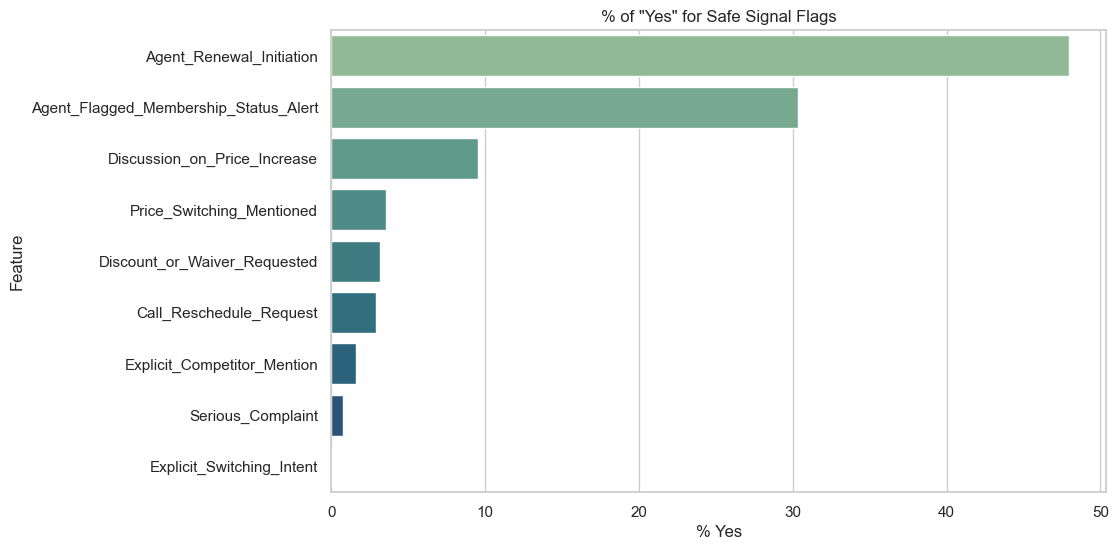

In [41]:
safe_flags = [
    'Discount_or_Waiver_Requested',
    'Discussion_on_Price_Increase',
    'Explicit_Competitor_Mention',
    'Call_Reschedule_Request',
    'Agent_Flagged_Membership_Status_Alert',
    'Explicit_Switching_Intent',
    'Price_Switching_Mentioned',
    'Agent_Renewal_Initiation',
    'Serious_Complaint'
]

# Calculate % Yes for each safe flag
yes_rates = []
for col in safe_flags:
    if col in df.columns:
        counts = df[col].value_counts(normalize=True)
        # Getting percentage of 'Yes'
        yes_pct = counts.get('Yes', 0) * 100
        yes_rates.append({'Feature': col, '% Yes': yes_pct})

rates_df = pd.DataFrame(yes_rates).sort_values(by='% Yes', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=rates_df, y='Feature', x='% Yes', palette='crest')
plt.title('% of "Yes" for Safe Signal Flags')
plt.xlabel('% Yes')
plt.show()

## Competitor Intelligence
This is business gold: which competitor is stealing your customers?

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\1283548667.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=competitor_counts.index, x=competitor_counts.values, ax=ax[0], palette='flare')
C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\1283548667.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=comp_val.index, x=comp_val.values, ax=ax[2], palette='flare')
C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\1283548667.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


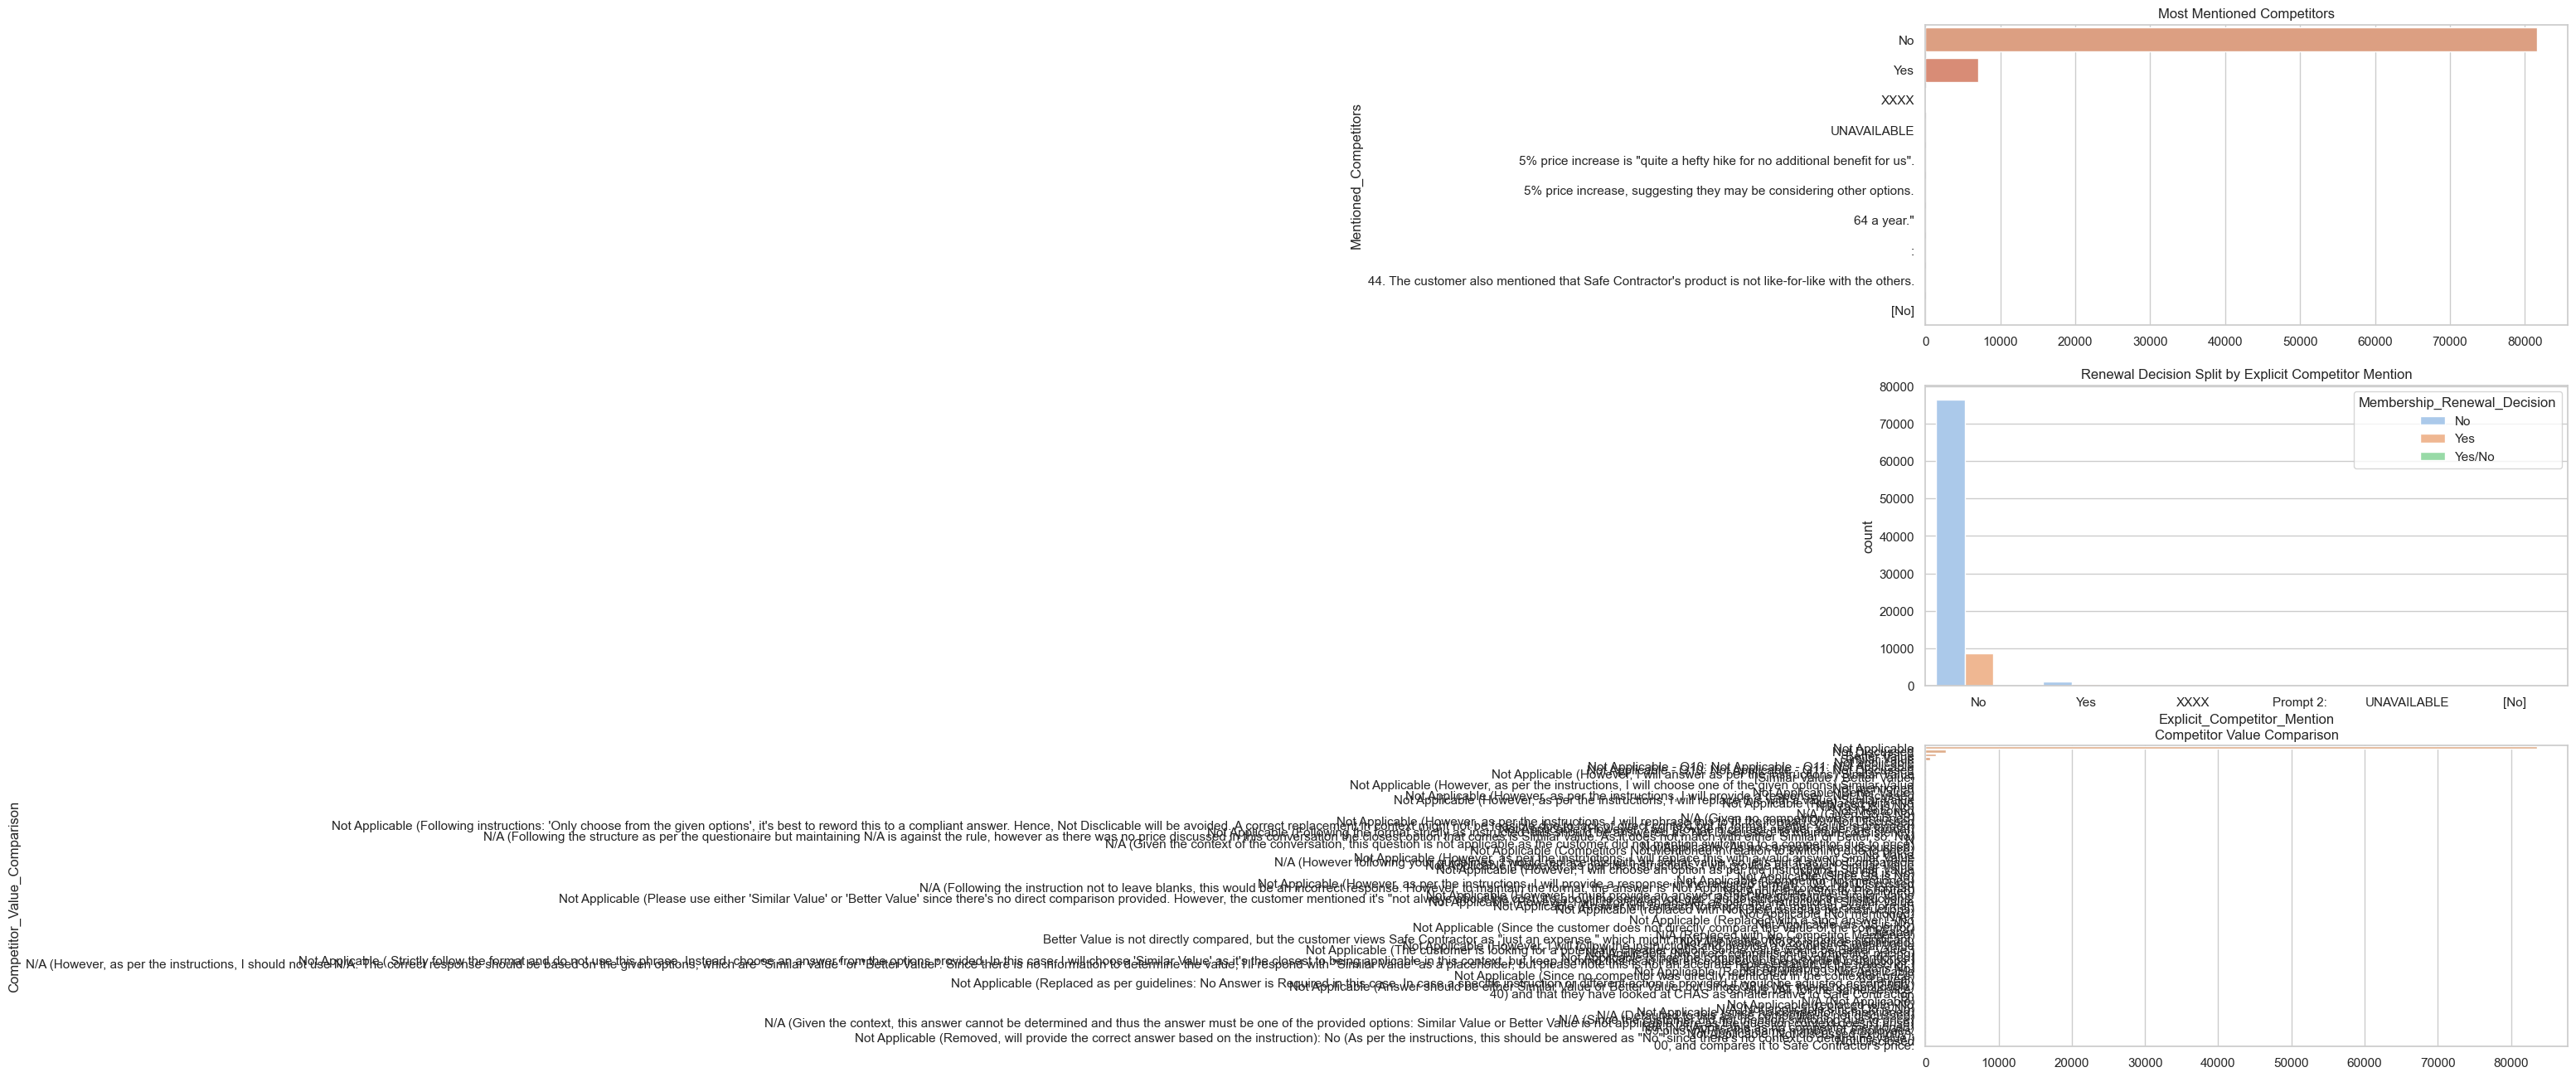


Competitor_Benefits_Mentioned:
Competitor_Benefits_Mentioned
Not Applicable                                                                                                                                64405
Not Discussed                                                                                                                                 15687
Discounts                                                                                                                                      2345
Better service                                                                                                                                 1656
Offering                                                                                                                                        908
                                                                                                                                              ...  
Cost-saving                                       

In [42]:
fig, ax = plt.subplots(3, 1, figsize=(10, 16))

# Which competitors are named most?
competitor_counts = df['Mentioned_Competitors'].value_counts().head(10)
sns.barplot(y=competitor_counts.index, x=competitor_counts.values, ax=ax[0], palette='flare')
ax[0].set_title('Most Mentioned Competitors')

# Renewal rate split by Explicit_Competitor_Mention = Yes vs No
sns.countplot(data=df, x='Explicit_Competitor_Mention', hue='Membership_Renewal_Decision', ax=ax[1], palette='pastel')
ax[1].set_title('Renewal Decision Split by Explicit Competitor Mention')

# Competitor Value Comparison
comp_val = df['Competitor_Value_Comparison'].value_counts()
sns.barplot(y=comp_val.index, x=comp_val.values, ax=ax[2], palette='flare')
ax[2].set_title('Competitor Value Comparison')

plt.tight_layout()
plt.show()

print("\nCompetitor_Benefits_Mentioned:")
print(df['Competitor_Benefits_Mentioned'].value_counts())

## Price Objection Cluster

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\4094121799.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_df, y='Column', x='% Yes', palette='magma')


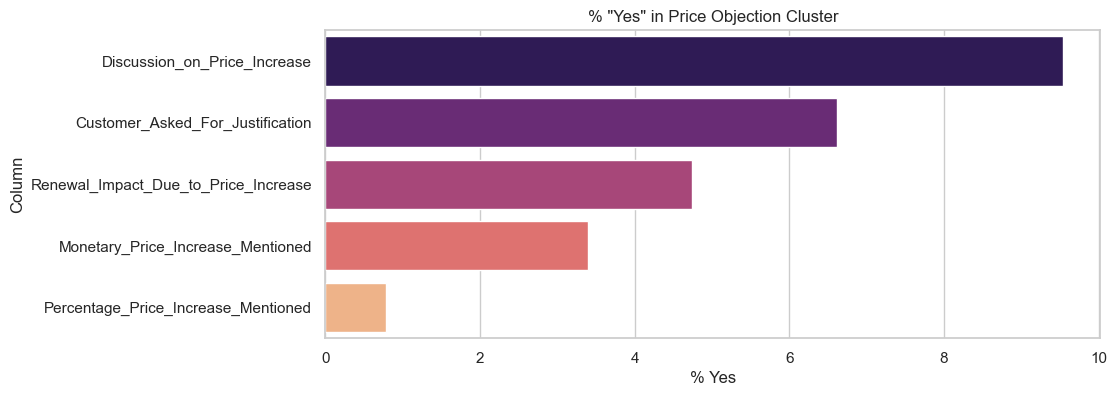

Typical Customer_Response when Price Discussed & Justification Asked (n=4306):
Customer_Response
Negative         2737
Neutral          1556
Positive           12
Not Discussed       1
Name: count, dtype: int64


In [43]:
price_cols = [
    'Discussion_on_Price_Increase',
    'Renewal_Impact_Due_to_Price_Increase',
    'Percentage_Price_Increase_Mentioned',
    'Customer_Asked_For_Justification',
    'Monetary_Price_Increase_Mentioned'
]

price_yes = []
for col in price_cols:
    if col in df.columns:
        pct = df[col].value_counts(normalize=True).get('Yes', 0) * 100
        price_yes.append({'Column': col, '% Yes': pct})

price_df = pd.DataFrame(price_yes).sort_values(by='% Yes', ascending=False)
plt.figure(figsize=(10, 4))
sns.barplot(data=price_df, y='Column', x='% Yes', palette='magma')
plt.title('% "Yes" in Price Objection Cluster')
plt.show()

# What is the typical Customer Response when price increase is discussed AND customer asks for justification
df_just = df[(df['Discussion_on_Price_Increase'] == 'Yes') & (df['Customer_Asked_For_Justification'] == 'Yes')]
print(f"Typical Customer_Response when Price Discussed & Justification Asked (n={len(df_just)}):")
print(df_just['Customer_Response'].value_counts())

## Discount Effectiveness
Direct input for the sales team.

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\1978120874.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=stays.index, x=stays.values, ax=ax[1], palette='Greens_r')


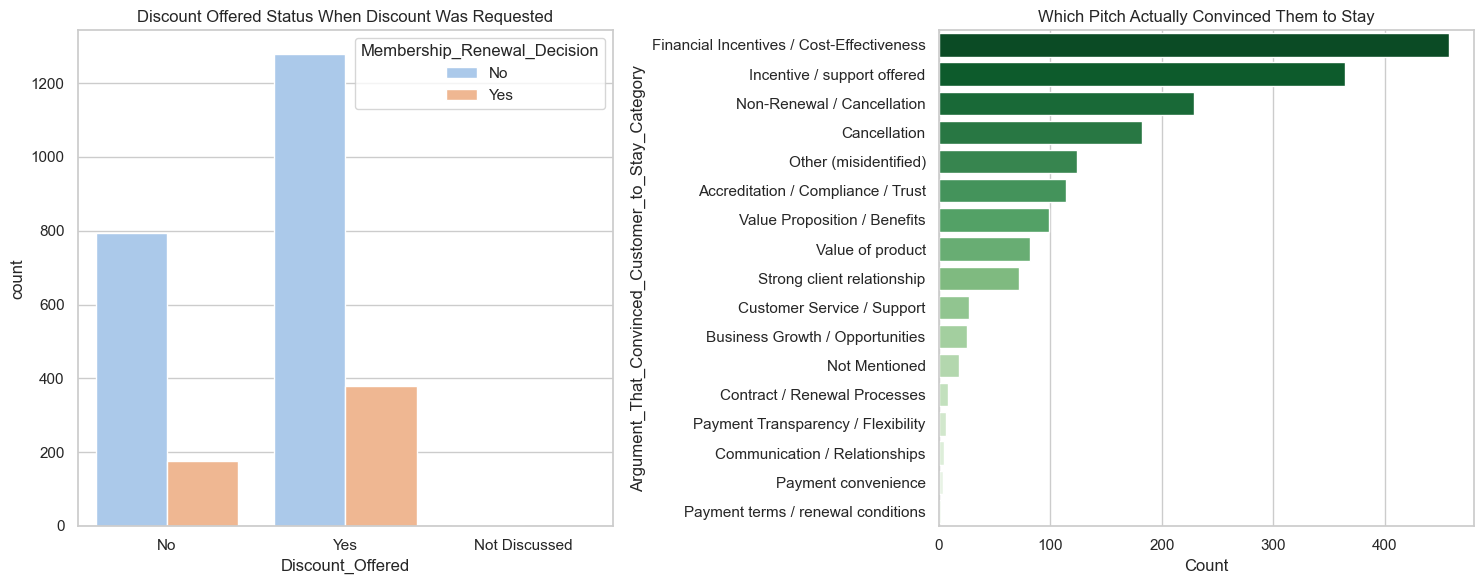

In [44]:
# How often is a requested discount actually given?
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

df_requested = df[df['Discount_or_Waiver_Requested'] == 'Yes']
sns.countplot(data=df_requested, x='Discount_Offered', hue='Membership_Renewal_Decision', ax=ax[0], palette='pastel')
ax[0].set_title('Discount Offered Status When Discount Was Requested')

# Which pitch actually works?
stays = df['Argument_That_Convinced_Customer_to_Stay_Category'].value_counts()
sns.barplot(y=stays.index, x=stays.values, ax=ax[1], palette='Greens_r')
ax[1].set_title('Which Pitch Actually Convinced Them to Stay')
ax[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## Agent Pitch & Response Categories
Understand the distribution of conversation types (e.g. Price, Expiration, Auto/Automatic, etc.)

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\4201460616.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=counts.index, x=counts.values, ax=ax[i], palette="Blues_d")
C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\4201460616.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=counts.index, x=counts.values, ax=ax[i], palette="Blues_d")
C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\4201460616.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=counts.index, x=counts.values, ax=ax[i],

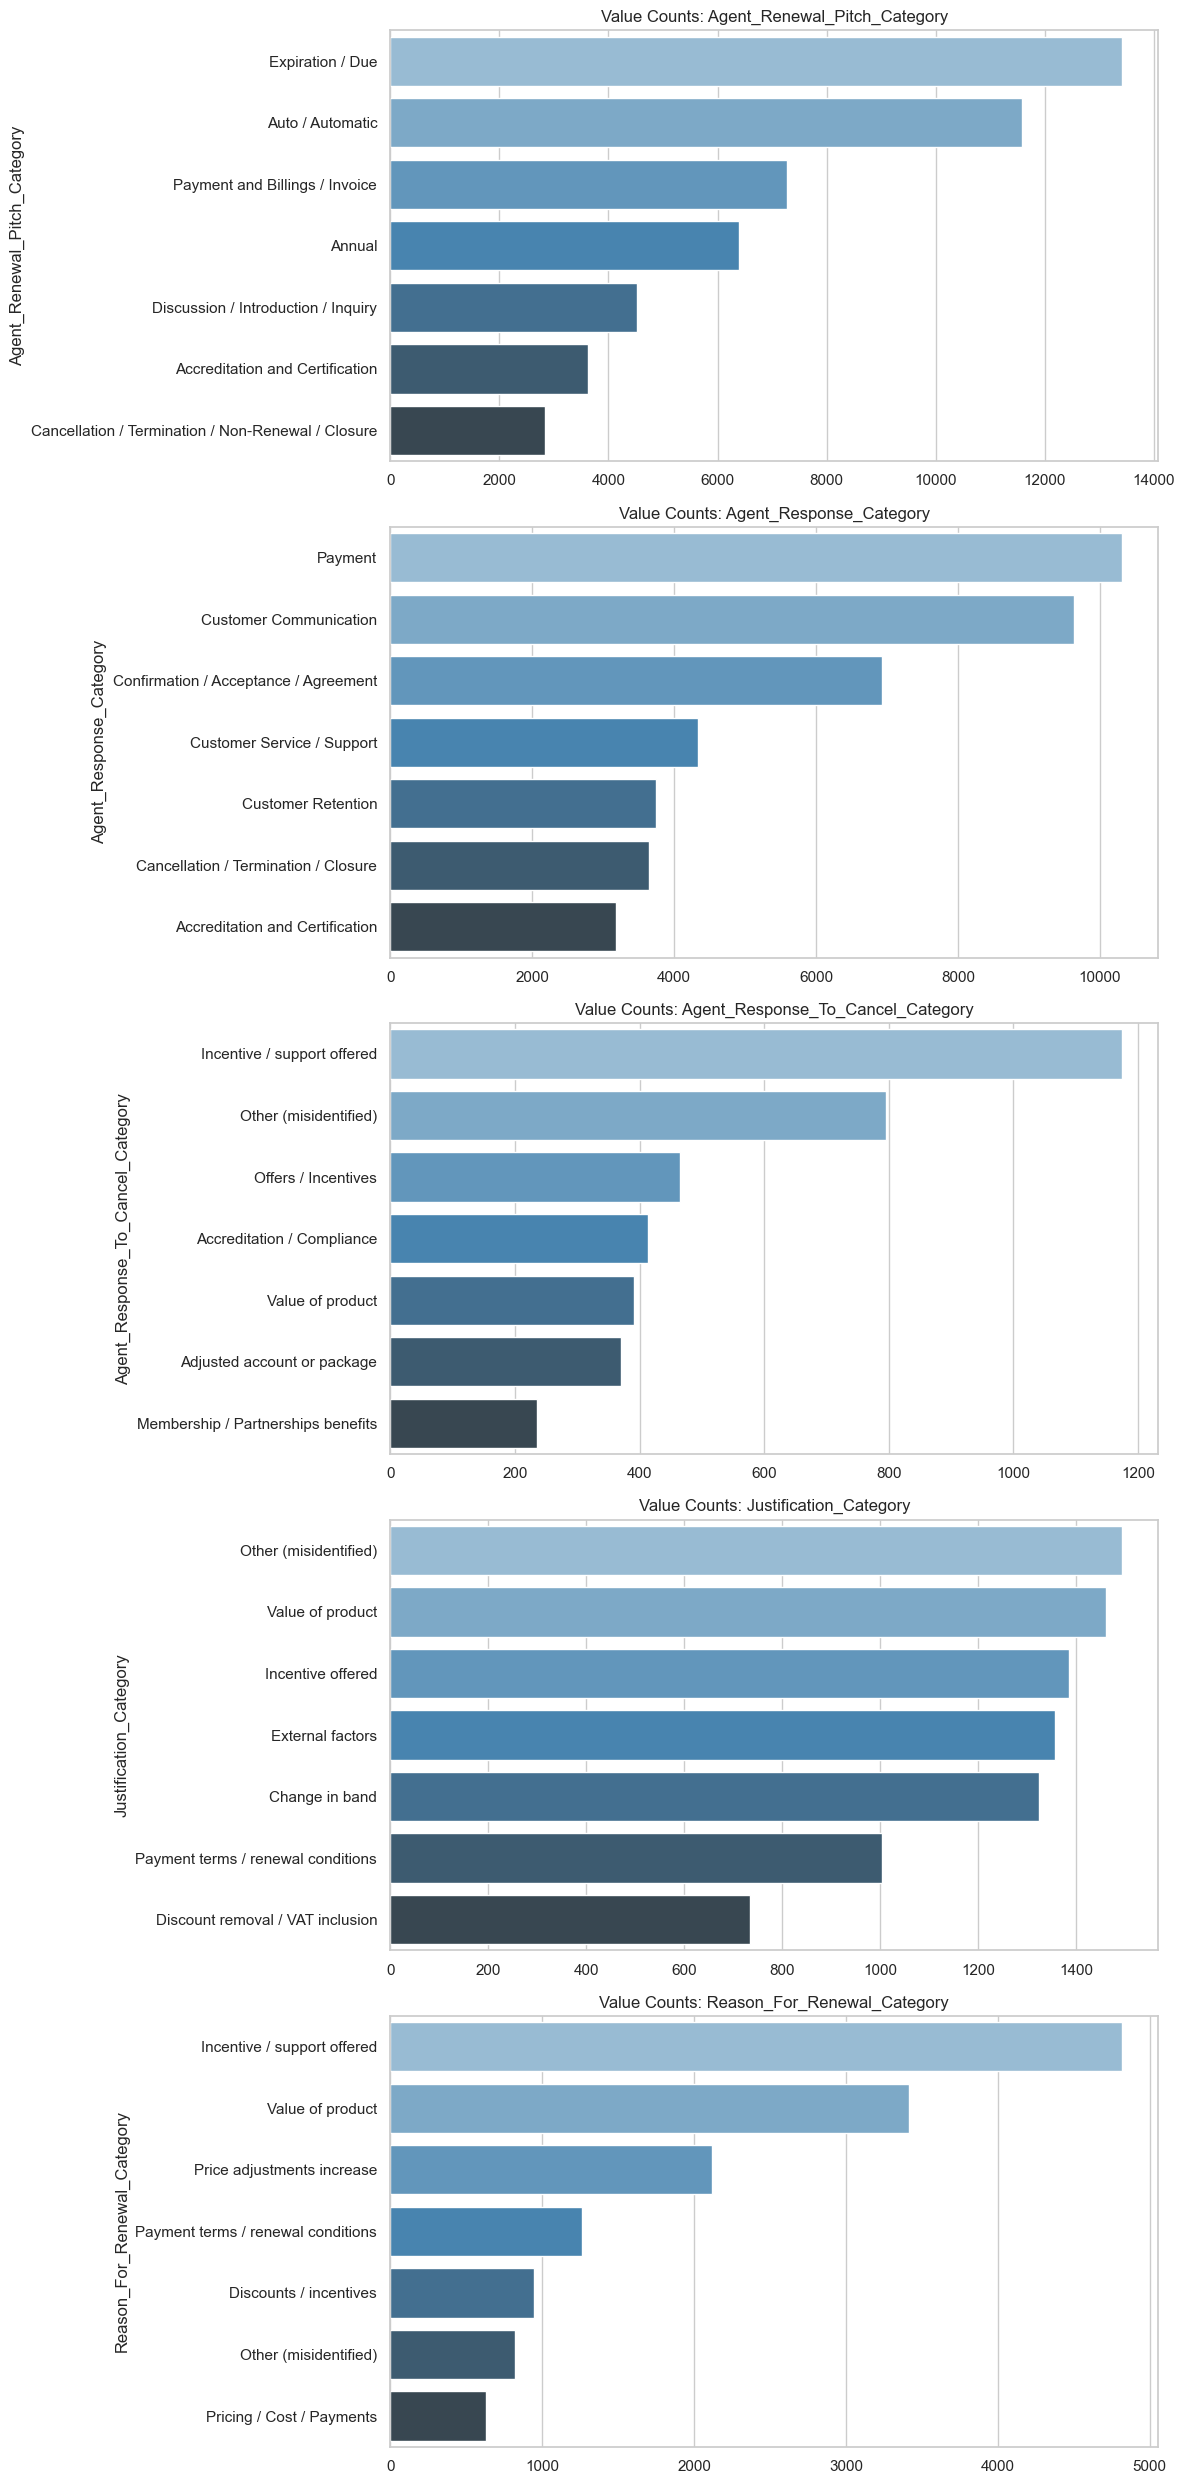

In [45]:
agent_cols = [
    'Agent_Renewal_Pitch_Category', 
    'Agent_Response_Category', 
    'Agent_Response_To_Cancel_Category', 
    'Justification_Category', 
    'Reason_For_Renewal_Category'
]

fig, ax = plt.subplots(len(agent_cols), 1, figsize=(12, 5 * len(agent_cols)))

for i, col in enumerate(agent_cols):
    if col in df.columns:
        counts = df[col].value_counts().head(7) # Top 7 to keep readable
        sns.barplot(y=counts.index, x=counts.values, ax=ax[i], palette="Blues_d")
        ax[i].set_title(f'Value Counts: {col}')
        ax[i].set_xlabel('')

plt.tight_layout()
plt.show()

## Temporal Patterns
Extract month from `Call_Date`. Flag mixed date formats.

C:\Users\BuddepuKedharVishnu\AppData\Local\Temp\ipykernel_2816\1370597105.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Call_Month', ax=ax[0], palette='viridis')


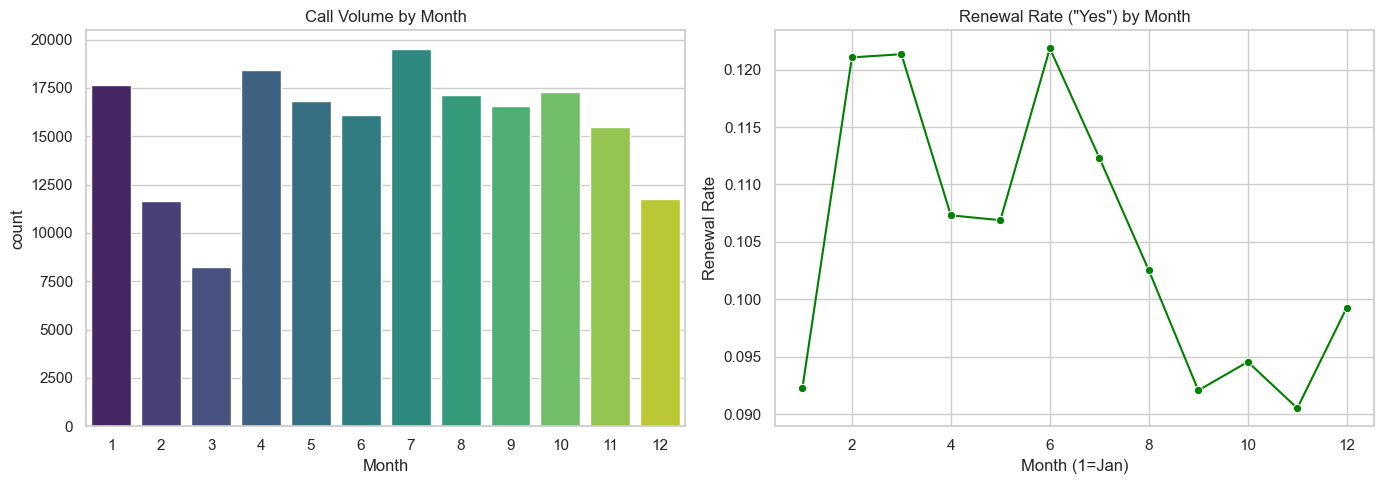

Unparsed dates (NaT): 0


In [46]:
# Flagging: Inconsistent date format like "29-01-2025" and others
df['Call_Date_Parsed'] = pd.to_datetime(df['Call_Date'], dayfirst=True, format='mixed', errors='coerce')
df['Call_Month'] = df['Call_Date_Parsed'].dt.month

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Call volume by month
sns.countplot(data=df, x='Call_Month', ax=ax[0], palette='viridis')
ax[0].set_title('Call Volume by Month')
ax[0].set_xlabel('Month')

# Monthly renewal rate
monthly_renewal = df.groupby('Call_Month')['Membership_Renewal_Decision'].value_counts(normalize=True).unstack().fillna(0)
if 'Yes' in monthly_renewal.columns:
    sns.lineplot(data=monthly_renewal, x=monthly_renewal.index, y='Yes', marker='o', ax=ax[1], color='green')
    ax[1].set_title('Renewal Rate ("Yes") by Month')
    ax[1].set_ylabel('Renewal Rate')
    ax[1].set_xlabel('Month (1=Jan)')

plt.tight_layout()
plt.show()

print(f"Unparsed dates (NaT): {df['Call_Date_Parsed'].isnull().sum()}")

## Correlation Heatmap
Let's map our 'Yes'/'No' flags to 1/0 to see how they correlate with each other and the proxy renewal label.

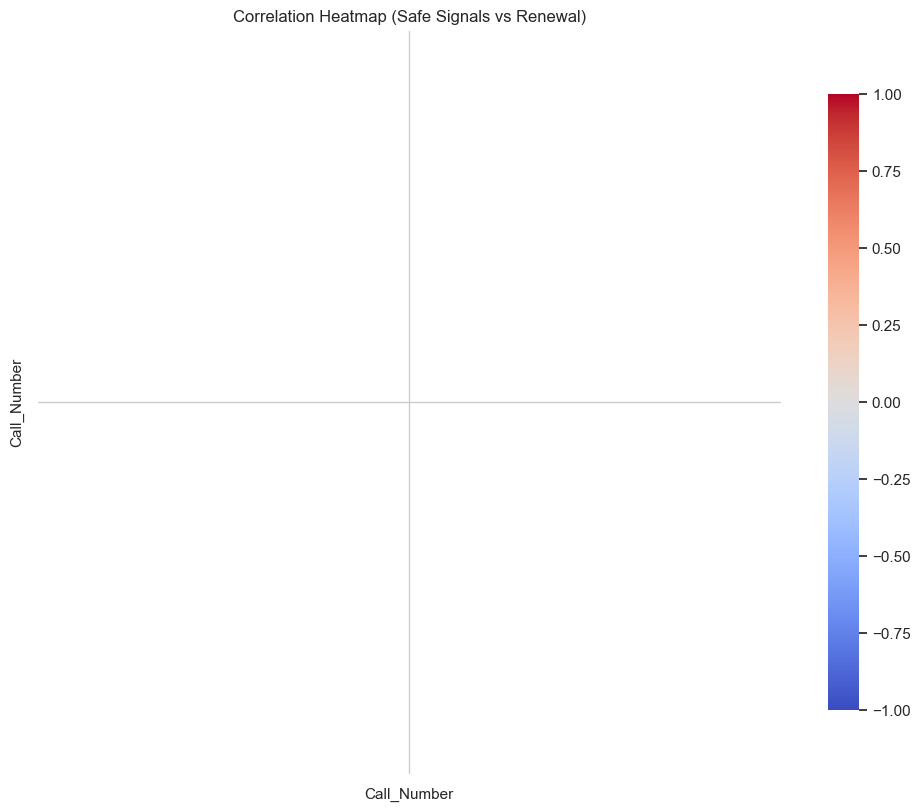

In [47]:
import numpy as np

# Prepare a subset for correlation
heatmap_cols = safe_flags + ['Membership_Renewal_Decision', 'Call_Number']
heatmap_df = df.copy()

for col in heatmap_cols:
    if col in heatmap_df.columns and heatmap_df[col].dtype == 'object':
        # Map known Yes/No to 1/0 (ignores dirty data artifacts by coercing them to NaN)
        heatmap_df[col] = heatmap_df[col].map({'Yes': 1, 'No': 0})

# Select only the explicitly defined numeric columns for plotting to avoid clutter
available_cols = [c for c in heatmap_cols if c in heatmap_df.columns]
numeric_heatmap_df = heatmap_df[available_cols].select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12, 10))
corr = numeric_heatmap_df.corr()

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap (Safe Signals vs Renewal)')
plt.show()

## Key Findings

* **Top churn reasons**: Highlighted in the initial exploration plots (e.g. complaints vs non-complaints).
* **Safe signal column value**: E.g. `Discount_or_Waiver_Requested` and `Explicit_Competitor_Mention` vs Reschedule.
* **Leakage columns**: ALL are documented in Cell 2 as absolutely prohibited for feature engineering.
* **Data preparation flags (for cleaner.py)**:
  * The blank unnamed column found between Explicit_Competitor_Mention and Explicit_Switching_Intent must be dropped immediately.
  * Inconsistent casing in `Call_Direction` must be normalized.
  * `Call_Date` mixed formats require standardized parsing.

## Correlation Heatmap (Numerical & Binary Features)
Converting 'Yes'/'No' categorical flags to 1/0 to see how they correlate with each other and numerical columns.